<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/225_likelihood.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>


(notebook-likelihood)=
# La verosimiglianza 

Oltre agli approcci frequentisti e bayesiani, esiste un terzo metodo fondamentale nell'ambito dell'inferenza statistica: la metodologia basata sulla verosimiglianza. Questo approccio consente ai ricercatori di valutare l'evidenza relativa quando si confrontano due modelli o ipotesi, in maniera simile alla metodologia bayesiana. Ciò che lo distingue è il suo esplicito rifiuto di incorporare informazioni pregresse (priori) nelle analisi statistiche.

Questo capitolo si concentra sulla funzione di verosimiglianza, concetto centrale che si estende attraverso tutti e tre gli approcci statistici, fungendo da collegamento tra i dati osservati e i parametri di un modello statistico specifico. La rilevanza della funzione di verosimiglianza risiede nella sua capacità di fornire un fondamento robusto per l'interpretazione e la quantificazione dell'adeguatezza dei dati ai modelli teorici. Questo la rende uno strumento cruciale per l'inferenza statistica, indispensabile per comprendere e valutare la conformità dei dati rispetto alle teorie proposte.

```{admonition} Obiettivi di apprendimento
Dopo aver completato questo capitolo, sarete in grado di:

- Comprendere il concetto di verosimiglianza e il suo ruolo nella dei parametri.
- Generare grafici della funzione di verosimiglianza binomiale.
- Generare grafici della funzione di verosimiglianza del modello gaussiano.
- Interpretare i grafici della funzione di verosimiglianza.
- Comprendere il concetto di stima di massima verosimiglianza.
```

## Preparazione del Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
from scipy.integrate import quad
import arviz as az
import seaborn as sns

In [2]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## Il Principio della Verosimiglianza e la sua Formalizzazione

La funzione di verosimiglianza e la funzione di densità (o massa) di probabilità sono due concetti fondamentali in statistica che, nonostante condividano la stessa espressione matematica, rivestono ruoli e interpretazioni distinti a seconda del contesto in cui vengono applicati. La chiave per distinguere tra i due concetti risiede nel modo in cui trattiamo i dati e i parametri del modello.

Nel caso della funzione di densità (o massa) di probabilità, i parametri del modello sono fissati e l'obiettivo è valutare la probabilità di osservare un certo insieme di dati. Qui, i dati sono variabili, mentre i parametri sono considerati costanti. Per esempio, in un esperimento in cui lanciamo una moneta diverse volte, potremmo usare una distribuzione binomiale per calcolare la probabilità di ottenere un certo numero di teste, assumendo un valore noto e fisso per la probabilità di ottenere testa in un singolo lancio.

Al contrario, nella funzione di verosimiglianza, manteniamo i dati osservati come fissi e variamo i parametri del modello per valutare quanto bene questi ultimi si adattino ai dati osservati. Questo processo ci permette di esplorare la plausibilità di diversi valori dei parametri dati gli stessi dati. L'obiettivo è identificare il set di parametri che meglio spiega i dati osservati.

Formalmente, la relazione tra la funzione di verosimiglianza e la funzione di densità di probabilità è espressa come segue:

$$
L(\theta | y) \propto p(y | \theta),
$$

dove $L(\theta | y)$ rappresenta la funzione di verosimiglianza per i parametri $\theta$ dati gli osservazioni $y$, e $p(y | \theta)$ indica la probabilità (o densità) di osservare i dati $y$ dato un certo set di parametri $\theta$.

Prendiamo l'esempio del lancio di una moneta. Se osserviamo 7 teste su 10 lanci, la funzione di massa di probabilità della distribuzione binomiale ci permette di calcolare la probabilità di questo esito per un dato valore di $p$ (la probabilità di testa). In questo contesto, $p$ è fisso e i dati ($y = 7$ teste in $n = 10$ lanci) sono variabili. 

Dall'altro lato, se consideriamo $p$ variabile, la funzione di verosimiglianza ci permette di valutare come diversi valori di $p$ si adattano all'esito osservato di 7 teste su 10 lanci, mantenendo i dati osservati fissi.

È importante sottolineare che, benché le due funzioni condividano la stessa forma matematica, il loro utilizzo e interpretazione sono profondamente diversi. La funzione di densità di probabilità si concentra sulla probabilità degli esiti dati i parametri, mentre la funzione di verosimiglianza valuta la plausibilità dei parametri dati gli esiti. Questa distinzione è cruciale per l'inferenza statistica, permettendoci di stimare i parametri del modello che meglio si adattano ai dati osservati e di comprendere in modo più approfondito la struttura e le caratteristiche del fenomeno studiato.

## Verosimiglianza Binomiale

Proseguendo con l'esempio della distribuzione binomiale, approfondiamo la rilevanza della funzione di verosimiglianza nell'analisi statistica attraverso uno scenario pratico. Supponiamo di condurre un esperimento con un numero definito di prove $n$, ognuna delle quali può terminare con un successo o un fallimento, come nel caso dei lanci di una moneta. Se registriamo $y$ successi e $n - y$ fallimenti, la probabilità di osservare esattamente $y$ successi segue la funzione di massa di probabilità (FMP) binomiale, che è definita come:

$$
P(Y = y) = \binom{n}{y} \theta^y (1 - \theta)^{n - y},
$$

dove $\theta$ è la probabilità di successo in una singola prova di Bernoulli.

Nell'utilizzo della funzione di verosimiglianza, ci concentriamo su come i diversi valori di $\theta$ possono spiegare i dati osservati $y$. La verosimiglianza è espressa come:

$$
\mathcal{L}(\theta \mid y) = \theta^y (1 - \theta)^{n - y},
$$

dato che il coefficiente binomiale $\binom{n}{y}$, non dipendendo da $\theta$, può essere omesso per la semplicità della formulazione.

Per esemplificare, immaginiamo uno studio su un gruppo di 30 individui, di cui 23 presentano un atteggiamento negativo verso il futuro, un indicatore comune in pazienti con depressione {cite:p}`zetsche_2019future`. Qui, i nostri dati $y$ e $n$ sono fissi, e la funzione di verosimiglianza per $\theta$ sconosciuto diventa:

$$
\mathcal{L}(\theta \mid y) = \frac{(23 + 7)!}{23!7!} \theta^{23} (1 - \theta)^7.
$$

Valutando questa funzione per una serie di valori di $\theta$ possiamo determinare quale valore di $\theta$ rende i dati osservati più probabili. Procediamo simulando 100 valori equidistanti di $\theta$ nell'intervallo [0, 1] e calcoliamo la verosimiglianza per ciascuno di questi valori.


In [3]:
n = 30
y = 23

Creiamo i possibili valori del parametro $\theta$ per i quali calcoleremo la verosimiglianza.

In [4]:
theta = np.linspace(0.0, 1.0, num=100)
print(theta)

[0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919 0.2020202  0.21212121 0.22222222 0.23232323
 0.24242424 0.25252525 0.26262626 0.27272727 0.28282828 0.29292929
 0.3030303  0.31313131 0.32323232 0.33333333 0.34343434 0.35353535
 0.36363636 0.37373737 0.38383838 0.39393939 0.4040404  0.41414141
 0.42424242 0.43434343 0.44444444 0.45454545 0.46464646 0.47474747
 0.48484848 0.49494949 0.50505051 0.51515152 0.52525253 0.53535354
 0.54545455 0.55555556 0.56565657 0.57575758 0.58585859 0.5959596
 0.60606061 0.61616162 0.62626263 0.63636364 0.64646465 0.65656566
 0.66666667 0.67676768 0.68686869 0.6969697  0.70707071 0.71717172
 0.72727273 0.73737374 0.74747475 0.75757576 0.76767677 0.77777778
 0.78787879 0.7979798  0.80808081 0.81818182 0.82828283 0.83838384
 0.84848485 0.85858586 0.86868687 0.87878788 0.88888889 0.89898

Per esempio, ponendo $\theta = 0.1$ otteniamo il seguente valore dell'ordinata della funzione di verosimiglianza:

$$
\mathcal{L}(\theta \mid y) = \frac{(23 + 7)!}{23!7!} 0.1^{23} + (1-0.1)^7.
$$

In [5]:
stats.binom.pmf(y, n, 0.1)

9.737168290200003e-18

Ponendo $\theta = 0.2$ otteniamo il seguente valore dell'ordinata della funzione di verosimiglianza:

$$
\mathcal{L}(\theta \mid y) = \frac{(23 + 7)!}{23!7!} 0.2^{23} + (1-0.2)^7.
$$

In [6]:
stats.binom.pmf(y, n, 0.2)

3.581417234922211e-11

Se ripetiamo questo processo 100 volte, una volta per ciascuno dei valori $\theta$ che abbiamo elencato sopra, otteniamo 100 coppie di punti $\theta$ e $f(\theta)$. A tale fine, definiamo la seguente funzione.

In [7]:
def like(r, n, theta):
    return math.comb(n, r) * theta**r * (1 - theta) ** (n - r)

La curva che interpola i punti ottenuti è la funzione di verosimiglianza, come indicato dalla figura seguente.

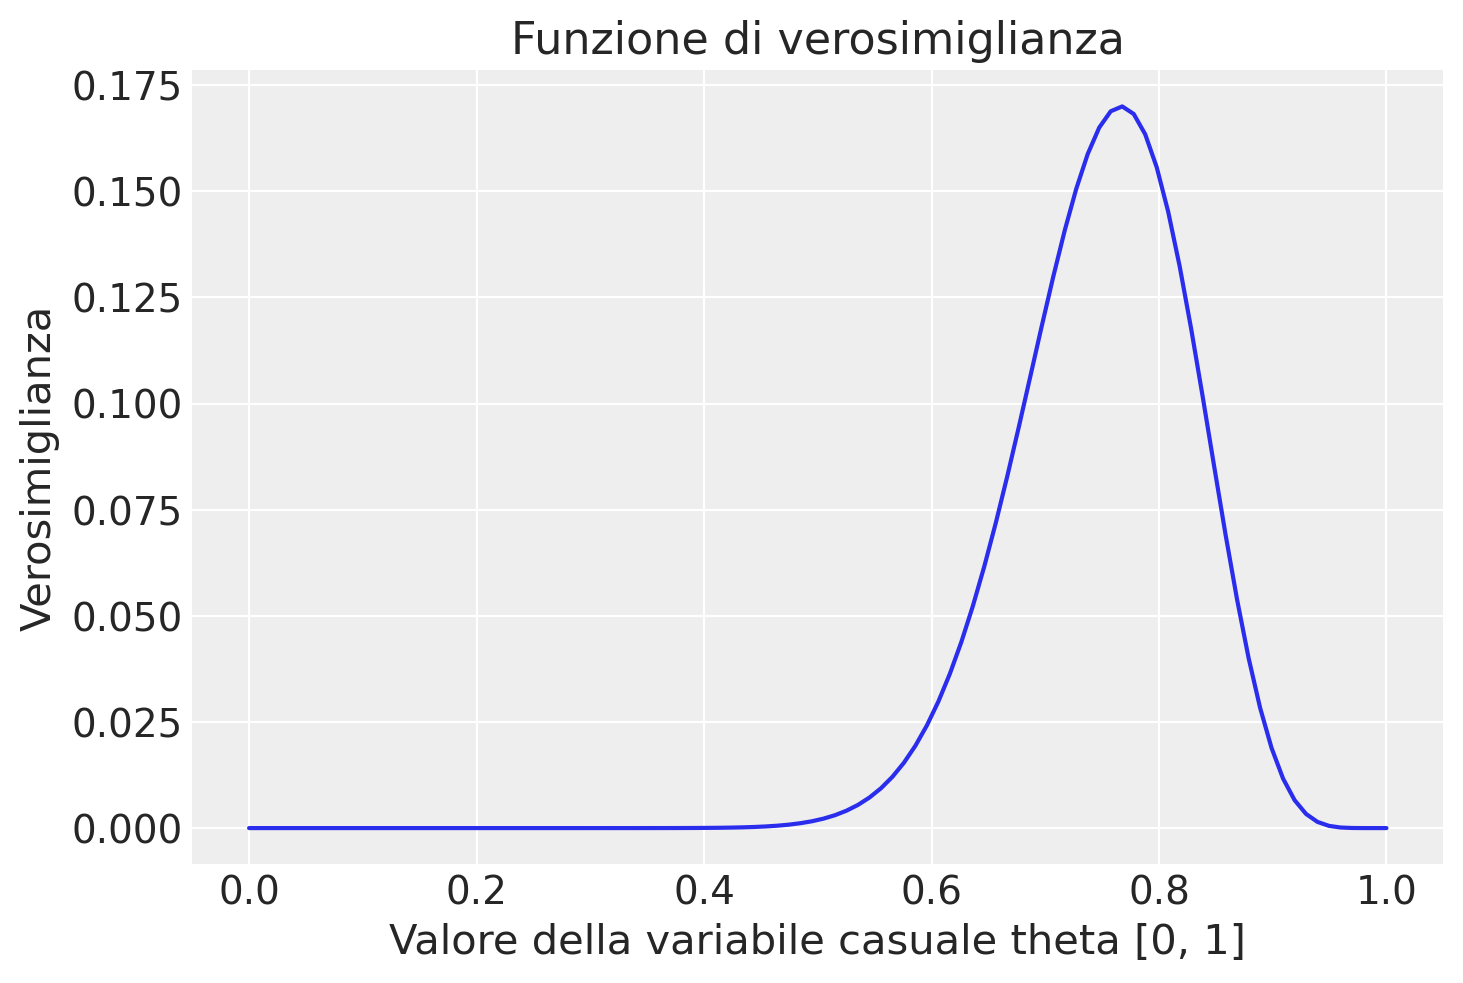

In [8]:
plt.figure()
plt.plot(theta, like(r=y, n=n, theta=theta), "-")
plt.title("Funzione di verosimiglianza")
plt.xlabel("Valore della variabile casuale theta [0, 1]")
plt.ylabel("Verosimiglianza");

### Interpretazione della Funzione di Verosimiglianza

L'interpretazione della funzione di verosimiglianza ci permette di misurare l'adattamento dei vari valori di $\theta$ ai dati. Il valore che massimizza la funzione indica la stima più plausibile di $\theta$ dati i dati osservati. In termini pratici, se per esempio il valore che massimizza la verosimiglianza è $\theta = 0.767$, ciò suggerisce che la probabilità più plausibile di successo (o atteggiamento negativo) nella nostra popolazione di studio è del 76.7%.

La determinazione numerica di questo valore ottimale può avvenire attraverso tecniche computazionali, come l'identificazione del punto di massimo della funzione di verosimiglianza tramite metodi di ottimizzazione. L'uso di librerie statistiche e matematiche in linguaggi di programmazione come Python consente di effettuare queste analisi con precisione e efficienza, offrendo una stima accurata del parametro $\theta$ che meglio si adatta ai dati osservati.

Questa metodologia, basata sull'uso della funzione di verosimiglianza, è cruciale per l'inferenza statistica, permettendo agli scienziati di stimare i parametri dei modelli statistici in modo informato e di valutare l'adeguatezza di tali modelli in rappresentanza dei dati reali.

In pratica, per identificare numericamente il valore ottimale di $ \theta $, si può localizzare l'indice nel vettore dei valori di verosimiglianza dove questa raggiunge il suo picco. Metodi computazionali, come l'uso della funzione `argmax` in NumPy, possono automatizzare questo processo. Una volta individuato l'indice che massimizza la verosimiglianza, si può risalire al valore corrispondente di $ \theta $ nel vettore dei parametri, ottenendo così la stima di $ \theta $ che rende i dati osservati più plausibili.

In [9]:
l = like(r=y, n=n, theta=theta)
l.argmax()

76

In [10]:
theta[76]

0.7676767676767677

È importante notare che, invece di utilizzare la funzione `like()` che abbiamo definito precedentemente per motivi didattici, è possibile ottenere lo stesso risultato utilizzando in modo equivalente la funzione `binom.pmf()`. 

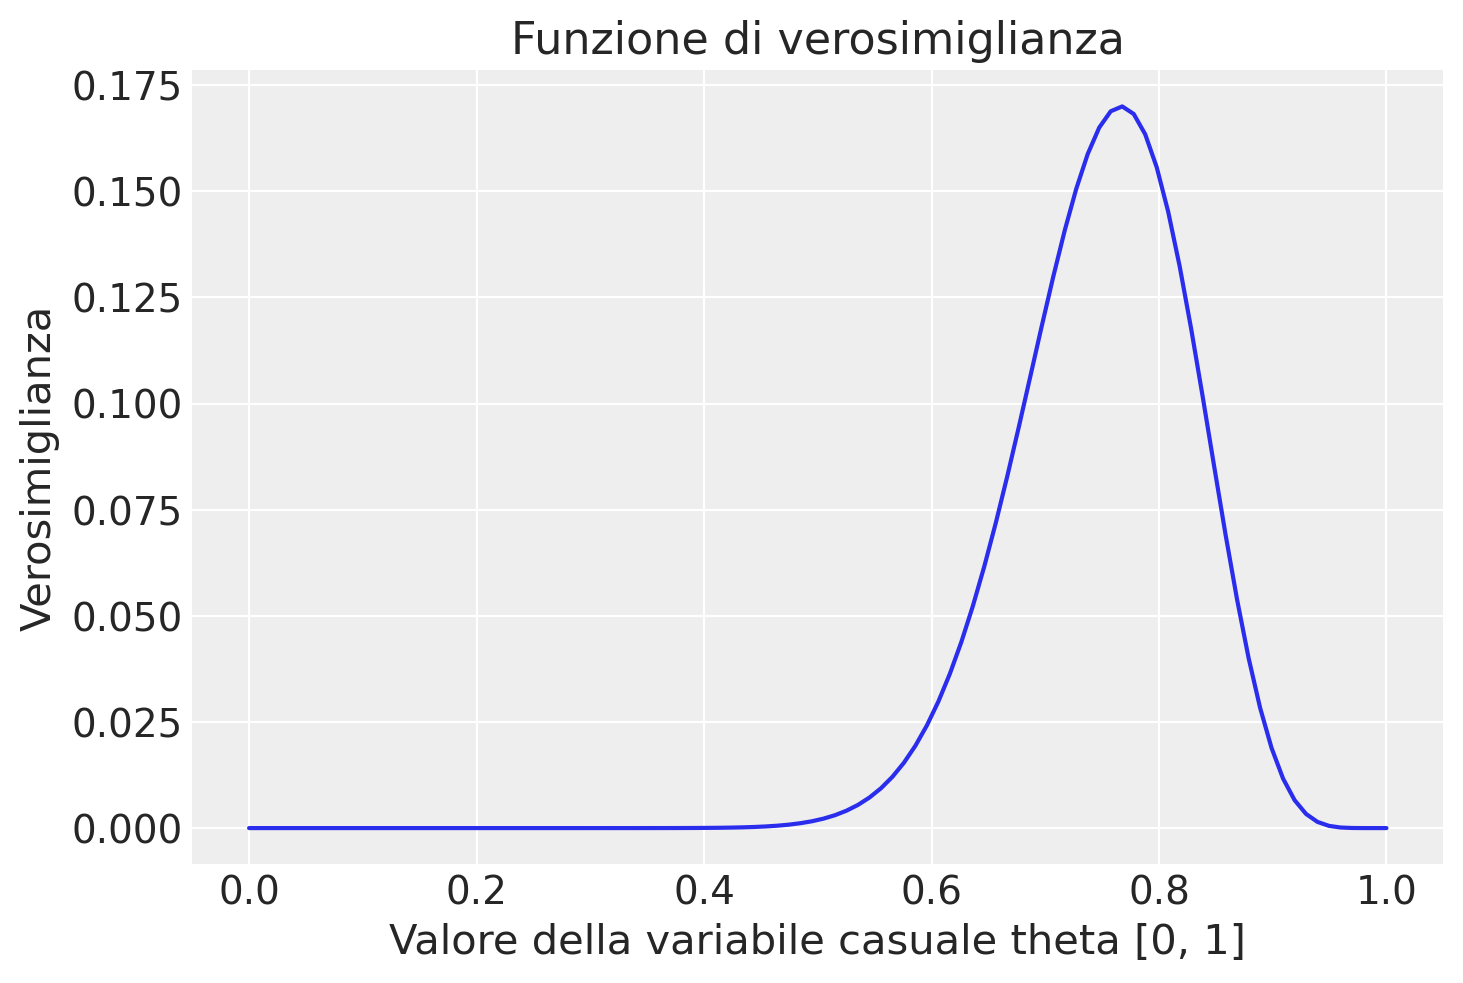

In [11]:
plt.figure()
plt.plot(theta, stats.binom.pmf(y, n, theta), "-")
plt.title("Funzione di verosimiglianza")
plt.xlabel("Valore della variabile casuale theta [0, 1]")
plt.ylabel("Verosimiglianza");

### La Funzione di Log-Verosimiglianza

Proseguendo con il nostro approfondimento sull'analisi statistica mediante la funzione di verosimiglianza, ci spostiamo verso una sua trasformazione matematica spesso preferita dagli statistici: la funzione di log-verosimiglianza. Il passaggio alla log-verosimiglianza, definita come il logaritmo naturale della funzione di verosimiglianza:

$$
\ell(\theta) = \log \mathcal{L}(\theta \mid y),
$$ (eq-loglike-definition)

non altera la posizione del massimo della funzione originale grazie alla proprietà di monotonicità del logaritmo. In termini pratici, ciò significa che il valore di $\theta$ che massimizza la log-verosimiglianza, $\hat{\theta}$, è lo stesso che massimizza la verosimiglianza originale:

$$
\hat{\theta} = \arg \max_{\theta \in \Theta} \ell(\theta) = \arg \max_{\theta \in \Theta} \mathcal{L}(\theta).
$$

Questo trasferisce il problema di massimizzazione da uno spesso complicato, a causa delle piccole magnitudini gestite nella verosimiglianza, a uno spesso più semplice e numericamente stabile grazie alla log-verosimiglianza. Quest'ultima esprime la relazione come una somma anziché come un prodotto:

$$
\ell(\theta \mid y) = y \log(\theta) + (n - y) \log(1 - \theta),
$$

rappresentando una forma più trattabile, soprattutto per calcoli complessi o per dataset di grande dimensione.

La preferenza per la log-verosimiglianza risiede in diverse ragioni pratiche e teoriche. Dal punto di vista numerico, lavorare con la log-verosimiglianza aiuta a evitare problemi di underflow, che possono verificarsi quando si moltiplicano tra loro probabilità molto piccole, tipiche di grandi set di dati. Convertendo i prodotti in somme, la log-verosimiglianza migliora la stabilità numerica dei calcoli. 

Ritornando all'esempio della distribuzione binomiale, l'applicazione della log-verosimiglianza per il calcolo del parametro $\theta$ che meglio si adatta ai dati osservati può essere eseguita con efficienza attraverso metodi computazionali. Per esempio, l'utilizzo di funzioni specifiche disponibili in pacchetti statistici, come `binom.logpmf()` in Python, permette di calcolare direttamente la log-verosimiglianza di un dato set di osservazioni per diversi valori di $\theta$. Questo approccio facilita la ricerca del valore di $\theta$ che massimizza la log-verosimiglianza, fornendo una stima accurata e computazionalmente efficiente del parametro.

L'adozione della funzione di log-verosimiglianza, quindi, non solo consente di affrontare i limiti pratici legati alla manipolazione di piccole probabilità, ma offre anche un quadro concettuale chiaro per l'interpretazione della plausibilità dei parametri del modello alla luce dei dati osservati. Questa trasformazione logaritmica rappresenta un passaggio cruciale nell'analisi inferenziale, consentendo di stimare i parametri dei modelli statistici con maggiore precisione e affidabilità.

Per illustrare questo concetto, riprendiamo l'esempio precedente e applichiamo la funzione di log-verosimiglianza per identificare il valore di $ \theta $ che massimizza questa funzione. La rappresentazione grafica della funzione di log-verosimiglianza fornisce ulteriori intuizioni sul comportamento di questa funzione.

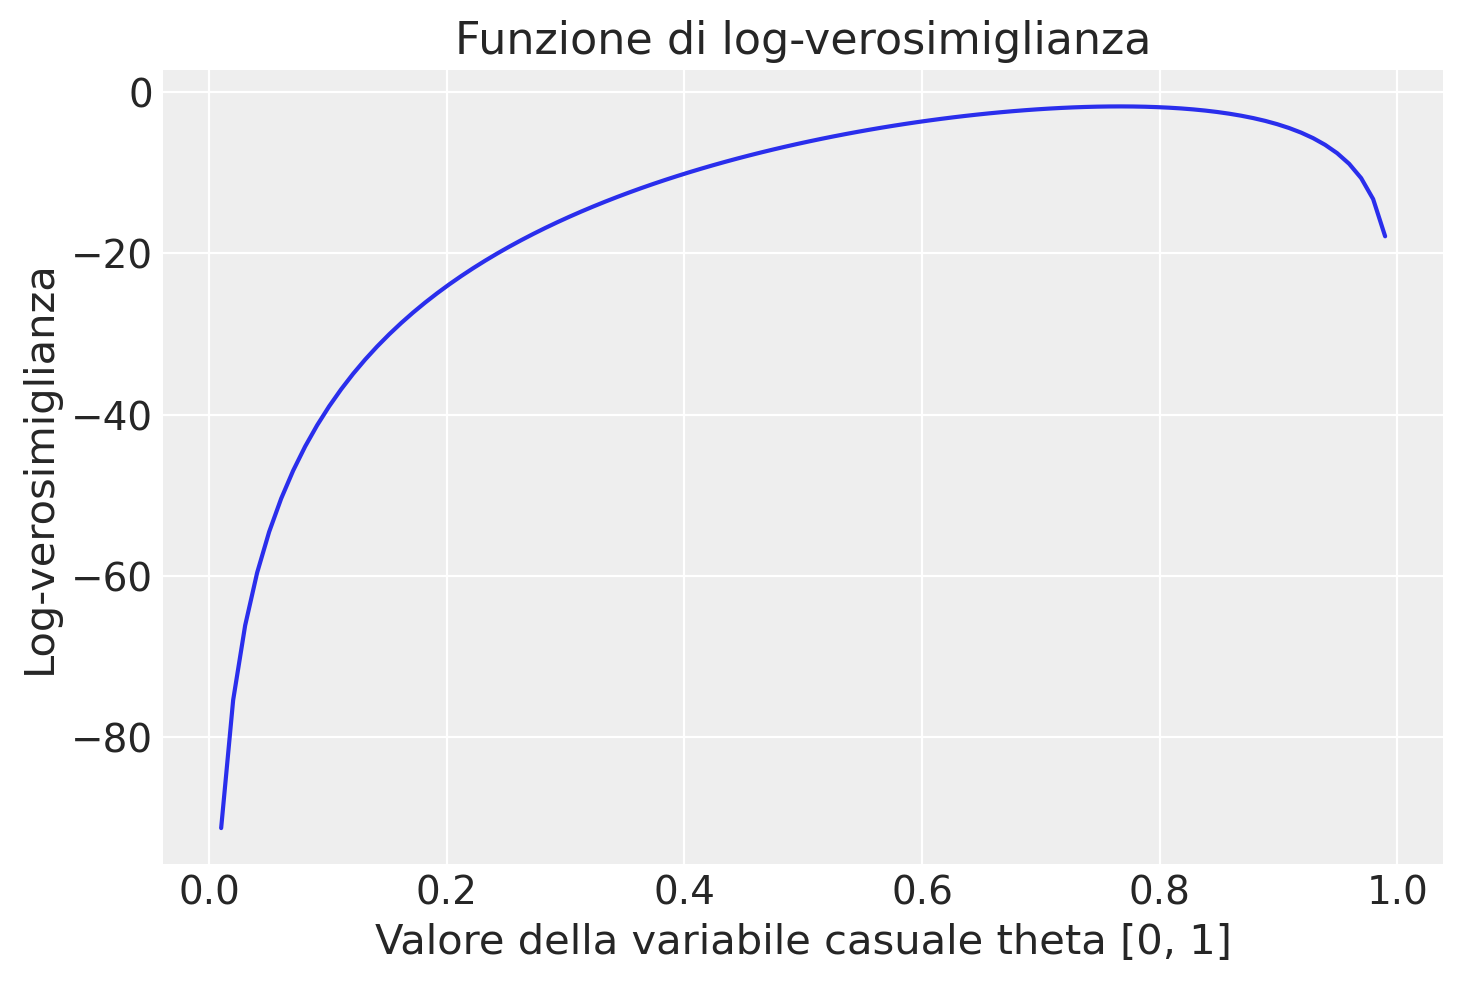

In [12]:
n = 30
r = 23
plt.figure()
plt.plot(theta, stats.binom.logpmf(y, n, theta), "-")
plt.title("Funzione di log-verosimiglianza")
plt.xlabel("Valore della variabile casuale theta [0, 1]")
plt.ylabel("Log-verosimiglianza");

Il risultato replica quello trovato in precedenza con la funzione di verosimiglianza.


In [13]:
ll = stats.binom.logpmf(y, n, theta)
ll.argmax()

76

In [14]:
theta[76]

0.7676767676767677

### Verosimiglianza Congiunta 

Proseguendo nella nostra esplorazione dell'inferenza statistica attraverso la funzione di verosimiglianza, ci concentriamo ora sul caso in cui abbiamo più osservazioni, tutte provenienti dalla stessa distribuzione binomiale e considerate indipendenti ed identicamente distribuite (IID). Tale scenario si presenta frequentemente nelle applicazioni pratiche, dove un insieme di $n$ osservazioni $Y = [y_1, y_2, \ldots, y_n]$ viene raccolto sotto le stesse condizioni sperimentali.

La chiave per analizzare queste osservazioni congiuntamente risiede nel calcolo della probabilità congiunta di $y_1, y_2, \ldots, y_n$ data un'unica probabilità di successo $\theta$ comune a tutte le prove. L'indipendenza delle osservazioni ci consente di esprimere questa probabilità congiunta come il prodotto delle probabilità individuali di ciascuna osservazione:

$$
p(y_1, y_2, \ldots, y_n \mid \theta) = \prod_{i=1}^{n} p(y_i \mid \theta) = \prod_{i=1}^{n} \text{Binomiale}(y_i \mid \theta).
$$

La bellezza di questo approccio sta nel fatto che la verosimiglianza congiunta, che rappresenta la plausibilità complessiva di $\theta$ data l'intera sequenza di osservazioni $Y$, è semplicemente il prodotto delle verosimiglianze individuali di ogni osservazione $y_i$ rispetto a $\theta$:

$$
\mathcal{L}(\theta \mid Y) = \prod_{i=1}^{n} \mathcal{L}(\theta \mid y_i) = \prod_{i=1}^{n} p(y_i \mid \theta).
$$

Questa formulazione della verosimiglianza congiunta non solo evidenzia quanto bene il parametro $\theta$ si adatta all'intero set di dati $Y$, ma offre anche una base metodologica solida per stimare $\theta$. Il parametro che massimizza la verosimiglianza congiunta, noto come stimatore di massima verosimiglianza (MLE) di $\theta$, è quello che si ritiene essere il più plausibile data l'osservazione dei dati.

L'analisi attraverso la funzione di verosimiglianza congiunta risulta particolarmente potente nell'inferenza statistica, poiché consente di combinare informazioni provenienti da molteplici osservazioni per formulare stime parametriche robuste e affidabili. Questo processo di aggregazione delle evidenze individuali in un'unica misura di plausibilità rappresenta un principio fondamentale nell'estrazione di insight quantitativi dai dati sperimentali.

## La Verosimiglianza Marginale

Avanzando nella nostra discussione sulla verosimiglianza, approfondiamo ora un passaggio cruciale nell'applicazione della teoria bayesiana: il concetto di verosimiglianza marginale. Questo approccio si rivela essenziale quando affrontiamo situazioni in cui il parametro di interesse, $\theta$, non è definito da un valore singolo e fisso, ma è invece descritto da una distribuzione di probabilità che riflette la nostra incertezza o variabilità su di esso.

In contesti pratici, non è raro incontrare scenari in cui $\theta$ può assumere una gamma di valori, ciascuno con una probabilità associata, piuttosto che un valore deterministico. L'integrazione del parametro $\theta$ permette di calcolare la probabilità complessiva (o verosimiglianza) di osservare un determinato risultato dati tutti i possibili valori di $\theta$, piuttosto che appoggiarsi a un'analisi basata su un singolo valore di $\theta$.

Consideriamo, per esempio, una situazione in cui stiamo osservando una sequenza di prove binomiali, con un risultato specifico di interesse (ad esempio, $k=7$ successi su $n=10$ prove). Se $\theta$ rappresenta la probabilità di successo in ciascuna prova e può assumere un insieme discreto di valori (per esempio, 0.1, 0.5, e 0.9) con probabilità uniforme, la verosimiglianza di osservare il nostro risultato specifico può essere espressa come:

$$p(k=7, n=10) = \sum_{\theta \in \{0.1, 0.5, 0.9\}} \binom{10}{7} \theta^7 (1-\theta)^3 p(\theta),$$

dove $p(\theta)$ rappresenta la probabilità associata a ciascun possibile valore di $\theta$.

Tuttavia, in molte applicazioni reali, $\theta$ può variare continuamente all'interno di un intervallo, come tra 0 e 1 per una distribuzione binomiale. In questi casi, il calcolo della verosimiglianza marginale richiede l'utilizzo dell'integrazione su tutto lo spazio dei valori possibili di $\theta$, riflettendo la gamma continua di possibili probabilità di successo. La formula si estende quindi a:

$$p(k=7, n=10) = \int_{0}^{1} \binom{10}{7} \theta^7 (1-\theta)^3 p(\theta) d\theta,$$

dove $p(\theta) d\theta$ rappresenta la densità di probabilità di $\theta$ su un intervallo infinitesimale, e l'integrale copre tutti i possibili valori di $\theta$ da 0 a 1.

L'adozione di questa procedura non solo arricchisce la nostra comprensione dei dati osservati considerando l'intera distribuzione di $\theta$, ma fornisce anche una base più solida per l'inferenza statistica in presenza di incertezza. Implementare questo calcolo nell'ambito di uno spazio continuo richiede l'utilizzo di tecniche di integrazione numerica, per le quali librerie come `scipy` in Python offrono strumenti efficaci e versatili.

Vediamo come potremmo eseguire questo calcolo in Python, utilizzando la libreria `scipy` per l'integrazione su uno spazio continuo:

In [15]:
# Definire la funzione di verosimiglianza
def likelihood(theta):
    return stats.binom.pmf(k=7, n=10, p=theta)

# Calcolare la verosimiglianza marginale integrando su θ
marginal_likelihood, _ = quad(lambda theta: likelihood(theta), 0, 1)

print("La verosimiglianza marginale è:", marginal_likelihood)

La verosimiglianza marginale è: 0.09090909090909094


Questo codice esegue l'integrazione della funzione di verosimiglianza binomiale su tutti i possibili valori di θ (da 0 a 1), fornendo così la verosimiglianza marginale per il nostro esempio. Questo processo ci permette di considerare l'incertezza su θ, offrendo una visione completa della verosimiglianza dell'evento osservato senza fissare θ a un singolo valore.

## Modello Gaussiano e Verosimiglianza

Ampliamo ora la nostra analisi al caso della distribuzione gaussiana. Inizieremo con la verosimiglianza associata a una singola osservazione $ Y $, per poi estendere la discussione a un insieme di osservazioni gaussiane indipendenti e identicamente distribuite (IID).

### Caso di una Singola Osservazione

Iniziamo esaminiamo il caso di una singola osservazione. Quale esempio, prendiamo in considerazione la situazione in cui una variabile casuale rappresenta il Quoziente d'Intelligenza (QI) di un individuo. Se consideriamo la distribuzione del QI come gaussiana, possiamo esprimere la funzione di verosimiglianza per un singolo valore osservato di QI tramite la formula della distribuzione gaussiana, che misura la probabilità di osservare quel particolare valore di QI dato un insieme di parametri specifici, $\mu$ (la media) e $\sigma$ (la deviazione standard). La verosimiglianza offre quindi un modo per quantificare quanto bene i parametri $\mu$ e $\sigma$ si accordano con il valore osservato di QI. 

Supponiamo che il QI osservato sia 114 e, per semplicità, assumiamo che la deviazione standard $\sigma$ sia conosciuta e pari a 15. Vogliamo esaminare un'ampia gamma di possibili valori per la media $\mu$, diciamo tra 70 e 160, e valutare quale di questi valori rende più plausibile l'osservazione fatta Definiamo quindi un insieme di 1000 valori per $\mu$ da esplorare:

In [3]:
mu = np.linspace(70.0, 160.0, num=1000)
y = 114

La nostra analisi consiste nell'applicare la funzione di densità di probabilità gaussiana a ciascuno di questi 1000 valori di $\mu$, mantenendo fisso il valore osservato di QI, $y=114$, e la deviazione standard, $\sigma=15$. In questo modo, possiamo costruire la funzione di verosimiglianza che esprime la plausibilità di ciascun valore di $\mu$ alla luce del QI osservato.

Il calcolo specifico della densità di probabilità per ogni valore di $\mu$ può essere eseguito con la funzione `norm.pdf` di `scipy.stats`, che accetta il valore osservato $y$, un array di medie (i nostri valori di $\mu$) e la deviazione standard $\sigma$. Per un singolo valore `mu` = 70, otteniamo

In [7]:
stats.norm.pdf(y, loc=70, scale=15)

0.00036007041207962535

Per il valore `mu` = 70.05 otteniamo

In [9]:
stats.norm.pdf(y, loc=70.05, scale=15)

0.00036360634900376967

e così via. Se usiamo utti i 1000 valori possibili di `mu`, otteniamo un vettore di 1000 risultati:

In [4]:
f_mu = stats.norm.pdf(y, loc=mu, scale=15)

Questo passaggio ci fornisce un array di valori che rappresentano la verosimiglianza di ciascun valore di $\mu$ data l'osservazione $y$. Tracciando questi valori `f_mu` in funzione di $\mu$, otteniamo una curva di verosimiglianza che illustra visivamente quanto bene ciascun valore di $\mu$ si adatta al dato osservato `y` = 114:

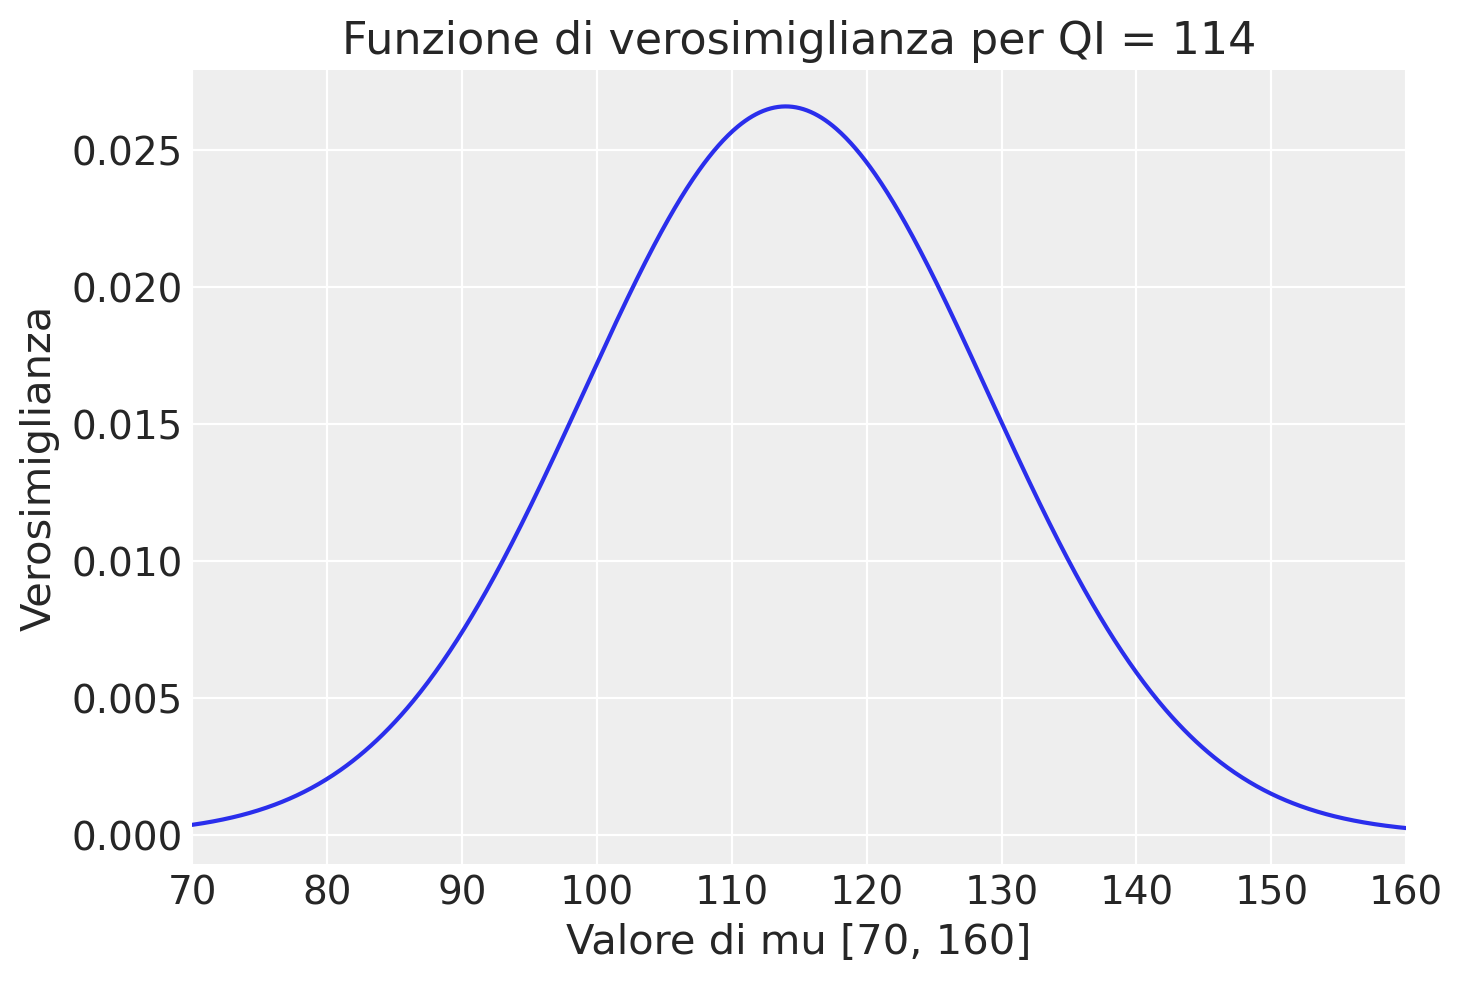

In [5]:
plt.figure()
plt.plot(mu, f_mu, "-")
plt.title("Funzione di verosimiglianza per QI = 114")
plt.xlabel("Valore di mu [70, 160]")
plt.ylabel("Verosimiglianza")
plt.xlim([70, 160])
plt.show()

Abbiamo dunque proceduto come nel caso della distribuzione binomiale esaminata in precedenza. Abbiamo utilizzato la formula 

$$
f(x | \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),
$$

tenendo costante il valore $x$ = 114 e considerando noto $\sigma$ = 15, e abbiamo applicato la formula 1000 volte facendo variare `mu` ogni volta utilizziando ciascuno dei valori definiti con `np.linspace(70.0, 160.0, num=1000)`.

La moda della distribuzione, si trova con

In [6]:
optimal_mu = mu[f_mu.argmax()]
print(optimal_mu)

113.96396396396396


In questo esempio, il valore di $\mu$ che massimizza la verosimiglianza è 113.96.

### Campione indipendente di osservazioni da una distribuzione gaussiana

Passiamo ora all'esame di un contesto più complesso: quello di un campione composto da $ n $ osservazioni indipendenti, tutte provenienti da una distribuzione gaussiana. Consideriamo questo insieme di osservazioni come realizzazioni indipendenti ed identicamente distribuite (i.i.d.) di una variabile casuale $ X $, che segue una distribuzione normale con media $ \mu $ e deviazione standard $ \sigma $, entrambi parametri sconosciuti. Denotiamo questa situazione con la notazione $ X \sim N(\mu, \sigma^2) $.

In presenza di osservazioni i.i.d., la densità di probabilità congiunta del campione è il prodotto delle funzioni di densità per ogni singola osservazione. Matematicamente, ciò si esprime attraverso l'equazione:

$$ p(y_1, y_2, \ldots, y_n | \mu, \sigma) = \prod_{i=1}^{n} p(y_i | \mu, \sigma), $$

dove $ p(y_i | \mu, \sigma) $ indica la funzione di densità gaussiana per l'osservazione $ y_i $, parametrizzata da $ \mu $ e $ \sigma $.

Se manteniamo i dati osservati come costanti, ciò che cambia in questa equazione quando variamo $ \mu $ e $ \sigma $ sono le probabilità associate ad ogni configurazione dei parametri, portandoci così alla funzione di verosimiglianza congiunta per il campione.

Consideriamo, per illustrare questa dinamica, il caso di uno studio clinico che misura i punteggi del Beck Depression Inventory II (BDI-II) su trenta partecipanti. Supponiamo che questi punteggi seguano una distribuzione normale. Dati i punteggi BDI-II per i trenta partecipanti, il nostro obiettivo è costruire una funzione di verosimiglianza per questi dati, assumendo che la deviazione standard $ \sigma $ sia nota e pari alla deviazione standard campionaria di 6.50.

Per la totalità del campione, la densità di probabilità congiunta diventa quindi il prodotto delle densità per ogni osservazione. Di conseguenza, la funzione di verosimiglianza per il campione intero è rappresentata dal prodotto delle densità di probabilità di tutte le osservazioni.

In questo contesto, ogni possibile valore di $ \mu $ viene valutato in termini di verosimiglianza. Per esemplificare, consideriamo un range di 1000 valori per $ \mu $ e calcoliamo la funzione di verosimiglianza per ognuno di questi. Per rendere più gestibili i calcoli, utilizziamo il logaritmo della funzione di verosimiglianza.

Definendo una funzione `log_likelihood` in Python che accetta i punteggi BDI-II $ y $, un valore medio $ \mu $, e imposta $ \sigma $ al valore noto, possiamo calcolare la log-verosimiglianza per un'ampia gamma di valori di $ \mu $ entro un intervallo specifico. Ciò ci permette di visualizzare la credibilità relativa di ciascun valore di $ \mu $ alla luce dei dati osservati.

Infine, il valore di $ \mu $ che massimizza la funzione di log-verosimiglianza corrisponde alla stima di massima verosimiglianza di $ \mu $ data la distribuzione dei punteggi BDI-II nel campione. Questo valore, nel nostro esempio, coincide con la media campionaria dei punteggi BDI-II, offrendo una stima concorde con l'intuizione che la media del campione sia un buon rappresentante del parametro $ \mu $ in una distribuzione normale.

I dati sono:

In [21]:
y = [
    26, 35, 30, 25, 44, 30, 33, 43, 22, 43, 24, 19, 39, 31, 25,
    28, 35, 30, 26, 31, 41, 36, 26, 35, 33, 28, 27, 34, 27, 22,
]

Il nostro scopo è sviluppare una funzione di verosimiglianza utilizzando le 30 osservazioni indicate sopra. Basandoci su studi precedenti, ipotizziamo che questi punteggi seguano una distribuzione normale. Assumiamo inoltre che la deviazione standard $ \sigma $ sia nota e corrisponda a quella osservata nel campione, ossia 6.50.

Per la prima osservazione del campione, dove $ y_1 = 26 $, la funzione di densità di probabilità si esprime come:

$$
f(26 \,|\, \mu, \sigma = 6.50) = \frac{1}{6.50\sqrt{2\pi}} \exp \left( -\frac{(26 - \mu)^2}{2 \cdot 6.50^2} \right).
$$

Estendendo questo calcolo all'intero campione, la funzione di densità di probabilità congiunta si ottiene come il prodotto delle densità di tutte le osservazioni individuali:

$$
f(y \,|\, \mu, \sigma = 6.50) = \prod_{i=1}^{n} f(y_i \,|\, \mu, \sigma = 6.50).
$$

Di conseguenza, la funzione di verosimiglianza, indicata con $ \mathcal{L}(\mu, \sigma = 6.50 \,|\, y) $, si determina moltiplicando insieme le densità di probabilità di tutte le osservazioni nel campione:

$$
\begin{aligned}
\mathcal{L}(\mu, \sigma=6.50 \,|\, y) &= \prod_{i=1}^{30} \frac{1}{6.50\sqrt{2\pi}} \exp \left( -\frac{(y_i - \mu)^2}{2 \cdot 6.50^2} \right) \\
&= \left( \frac{1}{6.50\sqrt{2\pi}} \right)^{30} \exp\left( -\sum_{i=1}^{30} \frac{(y_i - \mu)^2}{2 \cdot 6.50^2} \right).
\end{aligned}
$$

In questa formula, $ \mu $ rappresenta il parametro di interesse, la media della distribuzione, la cui stima massimizza la funzione di verosimiglianza. Se si considerano 1000 valori differenti per $ \mu $, dovremmo calcolare la funzione di verosimiglianza per ciascuno di questi valori.

Per rendere i calcoli più gestibili, è consigliabile utilizzare il logaritmo della funzione di verosimiglianza. In Python, possiamo definire una funzione `log_likelihood()` che accetta come argomenti `y`, `mu` e `sigma = true_sigma`. Per semplificare, impostiamo `true_sigma` uguale alla deviazione standard osservata nel campione.

In [22]:
true_sigma = np.std(y)
print(true_sigma)

6.495810615739622


In [23]:
def log_likelihood(y, mu, sigma=true_sigma):
    return np.sum(stats.norm.logpdf(y, loc=mu, scale=true_sigma))

Consideriamo, ad esempio, il valore $\mu_0 = \bar{y}$, ovvero


In [24]:
bar_y = np.mean(y)
print(bar_y)

30.933333333333334


L'ordinata della funzione di log-verosimiglianza in corrispondenza di $\mu = 30.93$ è


In [25]:
log_likelihood(y, 30.93, sigma=true_sigma)

-98.70288339960591

Troviamo ora i valori della log-verosimiglianza per ciascuno dei 1000 valori $\mu$ nell'intervallo $[\bar{y} - 2 \sigma, \bar{y} + 2 \sigma]$. Iniziamo a definire il vettore `mu`.


In [26]:
mu = np.linspace(np.mean(y) - 2 * np.std(y), np.mean(y) + 2 * np.std(y), num=1000)

Troviamo il valore dell'ordinata della funzione di log-verosimiglianza in corrispondenza di ciascuno dei 1000 valori `mu` che abbiamo definito.

In [27]:
ll = [log_likelihood(y, mu_val, true_sigma) for mu_val in mu]

Nel caso di un solo parametro sconosciuto (nel caso presente, $\mu$) è possibile rappresentare la log-verosimiglianza con una curva che interpola i punti (`mu`, `ll`). Tale funzione descrive la *credibilità relativa* che può essere attribuita ai valori del parametro $\mu$ alla luce dei dati osservati.

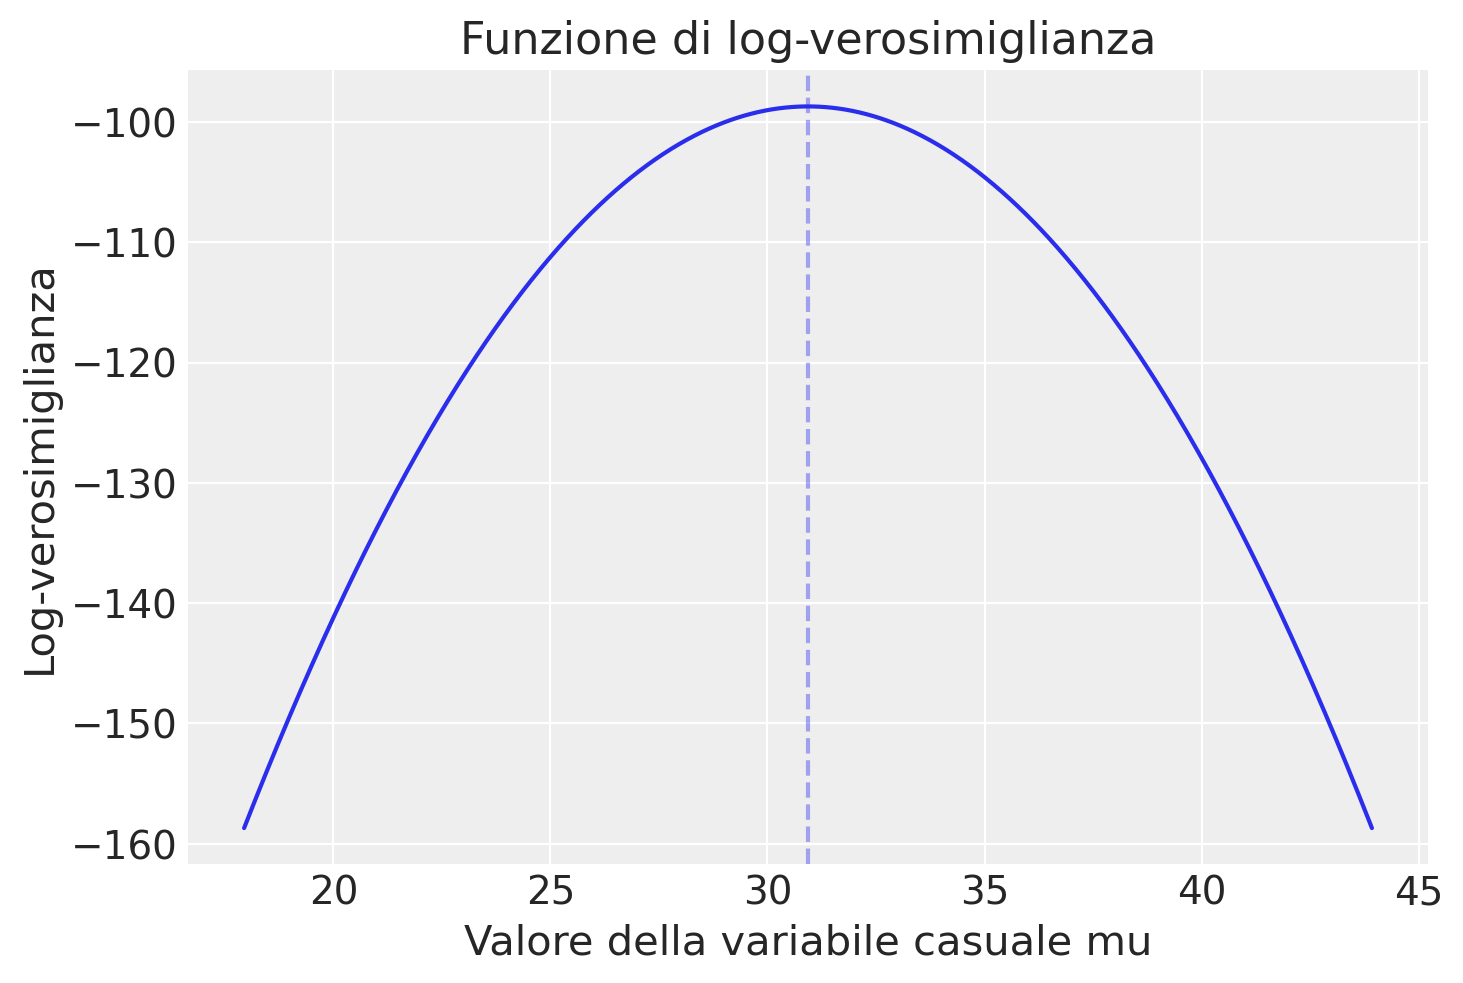

In [28]:
plt.figure()
plt.plot(mu, ll, "-")
plt.title("Funzione di log-verosimiglianza")
plt.xlabel("Valore della variabile casuale mu")
plt.ylabel("Log-verosimiglianza")
plt.axvline(x=np.mean(y), alpha=0.4, ls="--");

Il valore $\mu$ più credibile corrisponde al massimo della funzione di log-verosimiglinza e viene detto *stima di massima verosimiglianza*.

Il massimo della funzione di log-verosimiglianza, ovvero 30.93 per l'esempio in discussione, è identico alla media dei dati campionari. 

### Derivazione Formale

Per ottenere le stime di massima verosimiglianza (MLE) dei parametri $ \mu $ e $ \sigma^2 $ in una distribuzione gaussiana, ricorriamo all'analisi matematica, in particolare al calcolo delle derivate. La funzione di log-verosimiglianza $ \ell(\theta) $ per una distribuzione gaussiana è data da:

$$
\begin{aligned}
\ell(\mu, \sigma^2 \mid Y) &= \log \left( (2\pi\sigma^2)^{-n/2} \exp \left( -\frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - \mu)^2 \right) \right) \\
&= -\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - \mu)^2.
\end{aligned}
$$

L'obiettivo è massimizzare $ \ell(\mu, \sigma^2 \mid Y) $ rispetto a $ \mu $ e $ \sigma^2 $, ovvero:

$$
\max_{\mu, \sigma^2} \ell(\mu, \sigma^2 \mid Y).
$$

#### Stima di Massima Verosimiglianza per $ \mu $

Per trovare la stima di $ \mu $ che massimizza la funzione di log-verosimiglianza, calcoliamo la derivata parziale di $ \ell $ rispetto a $ \mu $ e la poniamo uguale a zero:

$$
\begin{aligned}
\frac{\partial \ell}{\partial \mu} &= \frac{\partial}{\partial \mu} \left( -\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (y_i - \mu)^2 \right) \\
&= \sum_{i=1}^n \frac{(y_i - \mu)}{\sigma^2} \\
&= \frac{1}{\sigma^2} \sum_{i=1}^n (y_i - \mu) = 0.
\end{aligned}
$$

Risolvendo questa equazione, otteniamo:

$$
\begin{aligned}
\hat{\mu}_{MLE} &= \frac{1}{n} \sum_{i=1}^n y_i \\
&= \bar{y}.
\end{aligned}
$$

La stima di massima verosimiglianza per $ \mu $ corrisponde quindi alla media aritmetica delle osservazioni.

#### Stima di Massima Verosimiglianza per $ \sigma^2 $

Una derivazione simile può essere effettuata per $ \sigma^2 $, e si può dimostrare che la stima di massima verosimiglianza per $ \sigma^2 $ è la varianza campionaria.

In sintesi, le stime di massima verosimiglianza per $ \mu $ e $ \sigma^2 $ in una distribuzione gaussiana coincidono con la media e la varianza campionaria, rispettivamente.

## Conclusione e Riflessioni Finali

La funzione di verosimiglianza rappresenta un elemento cruciale che collega i dati osservati ai parametri di un modello statistico. Essa fornisce una misura della plausibilità dei dati in relazione a diversi valori possibili dei parametri del modello. La strutturazione di una funzione di verosimiglianza richiede la considerazione di tre componenti fondamentali: il modello statistico che si presume abbia generato i dati, l'insieme di valori possibili per i parametri di tale modello e le osservazioni empiriche che effettivamente abbiamo a disposizione.

La funzione di verosimiglianza è centrale nella pratica dell'inferenza statistica. Essa ci permette di quantificare quanto bene differenti set di parametri potrebbero aver generato i dati osservati. Questo è fondamentale sia per la selezione del modello che per la stima dei parametri, e pertanto è indispensabile per un'analisi dati rigorosa e per un'interpretazione accurata dei risultati.

Un'applicazione pratica e illustrativa dei principi esposti in questo capitolo è fornita nel capitolo {ref}`notebook-rescorla-wagner`, che è un esempio di come la teoria della verosimiglianza possa essere applicata per affrontare questioni empiriche complesse in psicologia.

In sintesi, la comprensione e l'applicazione appropriata della funzione di verosimiglianza sono passaggi essenziali nel processo di analisi dati. Essa costituisce uno strumento indispensabile per chi è impegnato nella ricerca empirica e nell'interpretazione di dati complessi.

```{admonition} Esercizi
All'esame ti verrà chiesto di:

- Calcolare la funzione di verosimiglianza binomiale e riportare il valore della funzione in corrispondenza di specifici valori $\theta$.
- Calcolare la funzione di verosimiglianza del modello gaussiano, per $\sigma$ noto, e riportare il valore della funzione in corrispondenza di specifici valori $\mu$.
- Calcolare la stima di massima verosimiglianza.
- Rispondere a domande che implicano una adeguata comprensione del concetto di funzione di verosimiglianza.
```

## Informazioni sull'Ambiente di Sviluppo

In [29]:
%load_ext watermark
%watermark -n -u -v -iv -w -m

Last updated: Thu Mar 21 2024

Python implementation: CPython
Python version       : 3.11.8
IPython version      : 8.22.2

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.4.0
Machine     : arm64
Processor   : arm
CPU cores   : 8
Architecture: 64bit

matplotlib: 3.8.3
pandas    : 2.2.1
numpy     : 1.26.4
seaborn   : 0.13.2
arviz     : 0.17.1
scipy     : 1.12.0

Watermark: 2.4.3

